Install Relevant Libraries 


In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

Load dataset

In [2]:
df = pd.read_csv("../data/churn_dataset.csv")

df.head()

,industry,subscription_type,country,usage_frequency,login_activity,support_tickets,monthly_spend,payment_history,churn
0,Education,Pro,UK,39.0,52.0,3,486,On_time,0
1,Technology,Pro,Sri lanka,23.0,75.0,2,150,Late,0
2,Healthcare,Basic,UK,22.0,53.0,3,296,Failed,0
3,Retail,Basic,Australia,33.0,76.0,1,364,On_time,0
4,Retail,Basic,Germany,27.0,59.0,1,207,Failed,1


Dataset Overview 

In [3]:
df.shape

(5000, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   industry           5000 non-null   object 
 1   subscription_type  5000 non-null   object 
 2   country            5000 non-null   object 
 3   usage_frequency    4900 non-null   float64
 4   login_activity     4900 non-null   float64
 5   support_tickets    5000 non-null   int64  
 6   monthly_spend      5000 non-null   int64  
 7   payment_history    5000 non-null   object 
 8   churn              5000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 351.7+ KB


In [5]:
df.describe()

,usage_frequency,login_activity,support_tickets,monthly_spend,churn
count,4900.000000,4900.000000,5000.000000,5000.000000,5000.000000
mean,20.539592,60.067143,2.038600,261.879200,0.165800
std,11.447666,34.081494,1.437054,138.153989,0.371938
min,1.000000,1.000000,0.000000,20.000000,0.000000
25%,11.000000,30.000000,1.000000,142.000000,0.000000
50%,20.000000,61.000000,2.000000,262.500000,0.000000
75%,30.000000,90.000000,3.000000,379.250000,0.000000
max,40.000000,119.000000,11.000000,499.000000,1.000000


check missing values 

In [6]:
df.isnull().sum()

industry               0
subscription_type      0
country                0
usage_frequency      100
login_activity       100
support_tickets        0
monthly_spend          0
payment_history        0
churn                  0
dtype: int64

replace the missing values 

In [7]:
df["usage_frequency"].fillna(df["usage_frequency"].median(), inplace=True)
df["login_activity"].fillna(df["login_activity"].median(), inplace=True)

C:\Users\mt009\AppData\Local\Temp\ipykernel_10780\3511252478.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["usage_frequency"].fillna(df["usage_frequency"].median(), inplace=True)
C:\Users\mt009\AppData\Local\Temp\ipykernel_10780\3511252478.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

verify the data set

In [8]:
df.isnull().sum()

industry             0
subscription_type    0
country              0
usage_frequency      0
login_activity       0
support_tickets      0
monthly_spend        0
payment_history      0
churn                0
dtype: int64

Feature Engineering

01. Engagement Score

Logic:

Higher engagement → lower churn probability.

In [10]:
df["engagement_score"] = df["usage_frequency"] + df["login_activity"]
df.head()

,industry,subscription_type,country,usage_frequency,login_activity,support_tickets,monthly_spend,payment_history,churn,engagement_score
0,Education,Pro,UK,39.0,52.0,3,486,On_time,0,91.0
1,Technology,Pro,Sri lanka,23.0,75.0,2,150,Late,0,98.0
2,Healthcare,Basic,UK,22.0,53.0,3,296,Failed,0,75.0
3,Retail,Basic,Australia,33.0,76.0,1,364,On_time,0,109.0
4,Retail,Basic,Germany,27.0,59.0,1,207,Failed,1,86.0


02. Support Intensity

Logic:

Frequent support relative to usage → churn risk.

In [12]:
df["support_ratio"] = df["support_tickets"] / (df["usage_frequency"] + 1)
df

,industry,subscription_type,country,usage_frequency,login_activity,support_tickets,monthly_spend,payment_history,churn,engagement_score,support_ratio
0,Education,Pro,UK,39.0,52.0,3,486,On_time,0,91.0,0.075000
1,Technology,Pro,Sri lanka,23.0,75.0,2,150,Late,0,98.0,0.083333
2,Healthcare,Basic,UK,22.0,53.0,3,296,Failed,0,75.0,0.130435
3,Retail,Basic,Australia,33.0,76.0,1,364,On_time,0,109.0,0.029412
4,Retail,Basic,Germany,27.0,59.0,1,207,Failed,1,86.0,0.035714
...,...,...,...,...,...,...,...,...,...,...,...
4995,Healthcare,Basic,USA,33.0,62.0,4,43,On_time,0,95.0,0.117647
4996,Finance,Basic,Australia,7.0,112.0,2,277,Late,0,119.0,0.250000
4997,Technology,Basic,UK,7.0,80.0,1,299,On_time,0,87.0,0.125000
4998,Education,Pro,USA,33.0,78.0,4,251,Late,0,111.0,0.117647


Encode Categorical Features

by label encorder

In [14]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    "industry",
    "subscription_type",
    "country",
    "payment_history"
]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

df

,industry,subscription_type,country,usage_frequency,login_activity,support_tickets,monthly_spend,payment_history,churn,engagement_score,support_ratio
0,0,2,4,39.0,52.0,3,486,2,0,91.0,0.075000
1,4,2,3,23.0,75.0,2,150,1,0,98.0,0.083333
2,2,0,4,22.0,53.0,3,296,0,0,75.0,0.130435
3,3,0,0,33.0,76.0,1,364,2,0,109.0,0.029412
4,3,0,1,27.0,59.0,1,207,0,1,86.0,0.035714
...,...,...,...,...,...,...,...,...,...,...,...
4995,2,0,5,33.0,62.0,4,43,2,0,95.0,0.117647
4996,1,0,0,7.0,112.0,2,277,1,0,119.0,0.250000
4997,4,0,4,7.0,80.0,1,299,2,0,87.0,0.125000
4998,0,2,5,33.0,78.0,4,251,1,0,111.0,0.117647


Define Features and Target

In [16]:
X = df.drop("churn", axis=1)
y = df["churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (5000, 10)
Target shape: (5000,)


In [17]:
X.head

<bound method NDFrame.head of       industry  subscription_type  country  usage_frequency  login_activity  \
0            0                  2        4             39.0            52.0   
1            4                  2        3             23.0            75.0   
2            2                  0        4             22.0            53.0   
3            3                  0        0             33.0            76.0   
4            3                  0        1             27.0            59.0   
...        ...                ...      ...              ...             ...   
4995         2                  0        5             33.0            62.0   
4996         1                  0        0              7.0           112.0   
4997         4                  0        4              7.0            80.0   
4998         0                  2        5             33.0            78.0   
4999         4                  1        5             36.0            35.0   

      support_tickets

In [19]:
y.head()

0    0
1    0
2    0
3    0
4    1
Name: churn, dtype: int64

Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Import Models & Metrics

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

Train Logistic Regression

Logistic Regression Performance
              precision    recall  f1-score   support

           0       0.84      0.98      0.90       819
           1       0.60      0.14      0.23       181

    accuracy                           0.83      1000
   macro avg       0.72      0.56      0.57      1000
weighted avg       0.80      0.83      0.78      1000



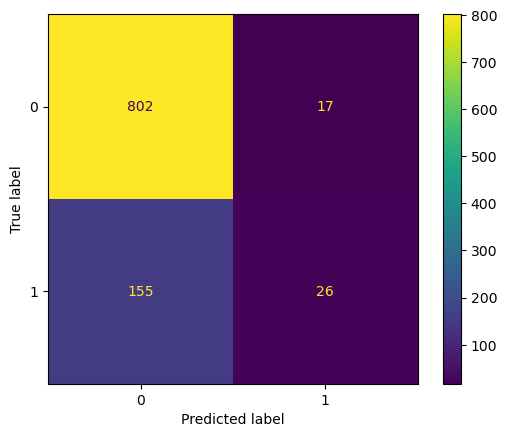

In [25]:
# Logistic Regression
model1 = LogisticRegression(max_iter=1000, random_state=42)
model1.fit(X_train, y_train)

y_pred_model1 = model1.predict(X_test)

print("Logistic Regression Performance")
print(classification_report(y_test, y_pred_lr))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)

Train Random Forest

Random Forest Performance
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       819
           1       0.61      0.31      0.42       181

    accuracy                           0.84      1000
   macro avg       0.74      0.64      0.66      1000
weighted avg       0.82      0.84      0.82      1000



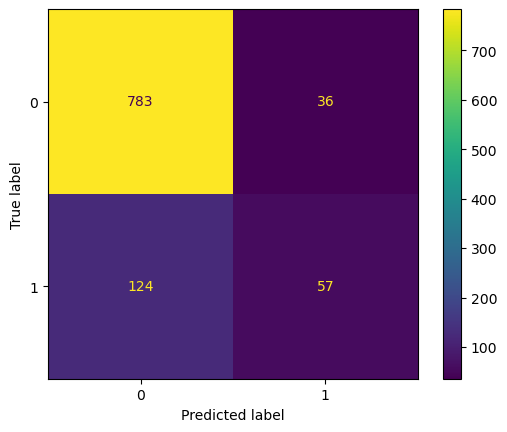

In [26]:
# Random Forest
model2 = RandomForestClassifier(n_estimators=200, random_state=42)
model2.fit(X_train, y_train)

y_pred_model2 = model2.predict(X_test)

print("Random Forest Performance")
print(classification_report(y_test, y_pred_model2))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_model2)

I choose random Forest model ,

In [30]:
import joblib
import os

os.makedirs("models", exist_ok=True)  # from project root
joblib.dump(model2, "models/churn_model.pkl")
print("Model saved at models/churn_model.pkl")

Model saved at models/churn_model.pkl
